In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from experiments import run_qber_experiment

In [3]:
interception_rates = np.linspace(0, 1, 11)

df = run_qber_experiment(n=5000, interception_rates=interception_rates, trials_per_rate=20)

df

,eve_interception_rate,average_qber,std_qber,expected_qber,trials_per_rate,qubits_per_trial
0,0.0,0.000000,0.000000,0.000,20,5000
1,0.1,0.026026,0.004005,0.025,20,5000
2,0.2,0.050896,0.004041,0.050,20,5000
3,0.3,0.075205,0.003599,0.075,20,5000
4,0.4,0.102926,0.004708,0.100,20,5000
5,0.5,0.124192,0.007021,0.125,20,5000
6,0.6,0.150533,0.007412,0.150,20,5000
7,0.7,0.171595,0.008581,0.175,20,5000
8,0.8,0.200023,0.007451,0.200,20,5000
9,0.9,0.223848,0.008213,0.225,20,5000


In [4]:
df.to_csv("../results/qber_experiment_results.csv", index=False)

print("Saved results to ../results/qber_experiment_results.csv")

Saved results to ../results/qber_experiment_results.csv


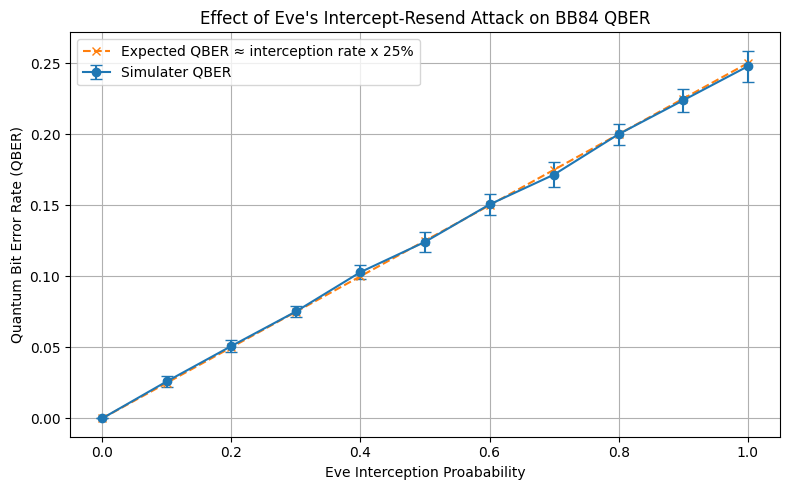

In [ ]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    df["eve_interception_rate"],
    df["average_qber"],
    yerr=df["std_qber"],
    marker="o",
    capsize=4,
    label="Simulated QBER"
)

plt.plot(
    df["eve_interception_rate"],
    df["expected_qber"],
    linestyle="--",
    marker="x",
    label="Expected QBER ≈ interception rate x 25%"
)

plt.xlabel("Eve Interception Proabability")
plt.ylabel("Quantum Bit Error Rate (QBER)")
plt.title("Effect of Eve's Intercept-Resend Attack on BB84 QBER")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../figures/qber_vs_eve_interception.png", dpi=300)
plt.show()

## Observation

The simulation shows that the Quantum Bit Error Rate increases as Eve intercepts a larger fraction of qubits.

For the intercept-resend attack, the expected relationship is approximately:

QBER ≈ Eve interception probability × 25%

This happens because Eve chooses the wrong basis around half the time. When she chooses the wrong basis, Bob has about a 50% chance of measuring a different bit from Alice. Therefore, intercepted qubits create errors at roughly 25% of the interception rate.